# Spatial Navigation using Grid Cells

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d, convolve
from tqdm import tqdm

## Exercise 0 — Getting Started: Ring Attractors in 1D

We begin with a 1D continuous ring attractor model. We simulate a field model integrated via the forward Euler method. The potential $s(x,t)$ of a neuron at position $x$ evolves according to:

$$
\tau \frac{ds(x,t)}{dt} = -s(x,t) + I_{rec}(x,t) + B(x,t)
$$

where $B(x,t)$ is an external input to the neuron, and the recurrent input $I_{rec}(x,t)$ is defined as the convolution of each neuron’s firing rate $r(x,t)$ with a synaptic weight kernel $W$ that depends on the distance between two neurons:

$$
I_{rec}(x,t) = \int W(x - x') r(x',t)\,dx'
$$

The firing rate $r(x,t)$ of a neuron at position $x$ is given by a simple ReLU activation on the potential:

$$
r(x,t) = \max(0, s(x,t))
$$

The recurrent connectivity kernel $W(x)$ is a Mexican-hat (difference of Gaussians) kernel:

$$
W(x) = A_{exc} e^{-x^2 / \sigma_{exc}^2} - A_{inh} e^{-x^2 / \sigma_{inh}^2}
$$

### 0.1
Write a Python function `mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)` that computes the 1D interaction weight at distance $x$.

In [17]:
def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    '''
    Compute the 1D mexican-hat weight kernel.
    
    Parameters:
    - x: array of positions
    - A_exc: amplitude of the excitatory component
    - sigma_exc: width of the excitatory component
    - A_inh: amplitude of the inhibitory component
    - sigma_inh: width of the inhibitory component
    Returns:
    - W: array of weights corresponding to positions in x
    '''
    exc = A_exc * np.exp(-x**2 / sigma_exc**2)
    inh = A_inh * np.exp(-x**2 / sigma_inh**2)
    W = exc - inh
    return W

### 0.2
Plot the weight kernel for an array of $M = 100$ neurons centered around 0 (i.e., $x \in [-\frac{M}{2}, \frac{M}{2})$, equally spaced), using parameters:

- $A_{exc} = 0.3$
- $\sigma_{exc} = 5.0$
- $A_{inh} = 0.2$
- $\sigma_{inh} = 10.0$

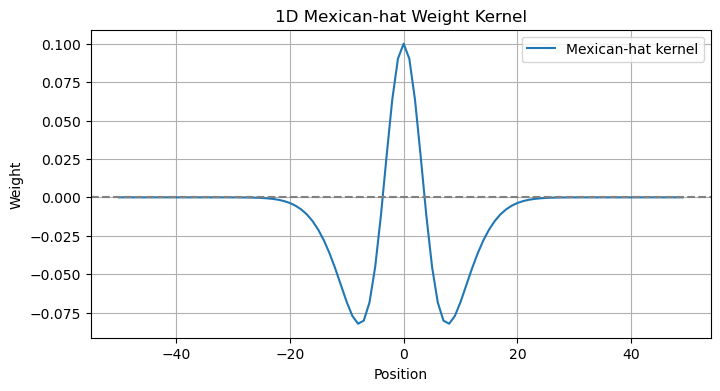

In [18]:
M = 100
x = np.linspace(-M/2, M/2, M, endpoint=False) # M/2 not included
A_exc = 0.3
sigma_exc = 5.0
A_inh = 0.2
sigma_inh = 10.0

W = mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh) # Compute the weight kernel

# plot
plt.figure(figsize=(8, 4))
plt.plot(x, W, label='Mexican-hat kernel')
plt.axhline(0, color='gray', linestyle='--')
plt.title('1D Mexican-hat Weight Kernel')
plt.xlabel('Position')
plt.ylabel('Weight')
plt.legend()
plt.grid()
plt.show()

### 0.3
Explain which biological feature of cortical connectivity this kernel represents, in terms of excitation and inhibition.

### Answer: 
The mexican hat represents local excitation and lateral inhibition.
- Local excitation: Neurons that are close to each other excite one another, as we can see with the narrow Gaussian around $x=0$.
- Lateral inhibition: Neurons that are not close enough to each other inhibit one another, as we can see with the negative Gaussian which is broader than the positive one (excitatory).

There is this difference because of the different sigmas (smaller for sigma_exc than sigma_inh). Biologically, this is due to excitatory pyramidal neurons make short-range synaptic connections with their neighbors and inhibitory interneurons inhibit neurons which are farther.

If we were to simply apply this connectivity scheme to $M$ neurons, it is not clear how the neurons at the boundary should be connected to other neurons. Here, we assume the network relies on periodic boundary conditions. Mathematically, this means that the connectivity kernel is periodic, i.e.:

$$
W(x + M) = W(x)
$$

for every $x$. Equivalently, we could imagine that the $M$ neurons lie on a ring.

To simulate the network, we will use the Forward Euler method with a time-step of $\Delta t = 1 \, \text{ms}$:

$$
s(x, t_{k+1}) = s(x, t_k) + \Delta t \cdot \frac{ds(x, t_k)}{dt}
$$

### 0.4
Use the forward Euler method with timestep $\Delta t = 1 \, \text{ms}$ to integrate the dynamics of this 1D network over 500 ms. Plot the evolution of the firing rate $r(x,t)$ of all neurons. (Suggestions: you could use a heat map to visualize this).

Parameters:

- $\tau = 10 \, \text{ms}$
- $B(x,t) = 1.0$

Randomly initialize the potentials $s(x,0)$ uniformly in $[0, 0.1]$.

Hint: To easily implement the convolution

$$
\int W(x - x') r(x') dx'
$$

discretely, you could first precompute the connectivity kernel as in Ex. 0.2 and then use `scipy.ndimage.convolve1d`, with proper mode to reflect the periodic boundary.

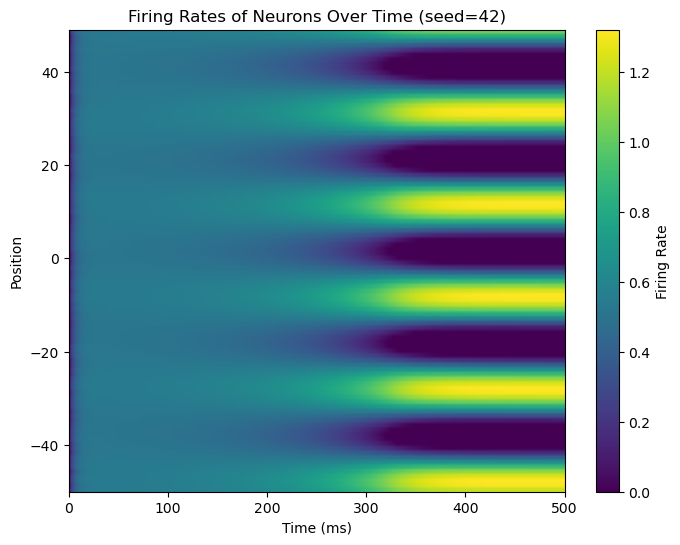

In [21]:
# Euler
def forward_Euler(M, W, B, dt, tau, n_steps, seed=42):
    rng = np.random.default_rng(seed=seed)

    s = rng.uniform(0,0.1, size=M) # potentials randomly initialized between 0 and 0.1
    r_history = np.zeros((n_steps, M)) # firing rates over time

    for t in range(n_steps):
        r = np.maximum(0, s) # firing rates
        Irec = convolve1d(r, W, mode='wrap') # recurrent input
        s = s + dt/tau * (-s + Irec + B) # Euler
        r_history[t] = r
    
    return r_history

# heatmap
def plot_firing_rates(r_history, x, n_steps, seed=42):
    plt.figure(figsize=(8, 6))
    plt.imshow(r_history.T, aspect='auto', origin='lower', extent=[0, n_steps, x[0], x[-1]])
    plt.colorbar(label='Firing Rate')
    plt.title(f'Firing Rates of Neurons Over Time (seed={seed})')
    plt.xlabel('Time (ms)')
    plt.ylabel('Position')
    plt.show()

# Parameters
n_steps = 500
M = 100
tau = 10 # ms
dt = 1 # ms
B = 1.0
W = mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh) # Compute the weight kernel

# Simulate
r_history = forward_Euler(M=M, W=W, B=B, dt=dt, tau=tau, n_steps=n_steps)
plot_firing_rates(r_history, x, n_steps)

### 0.5
Describe the behavior of the network. Use 3 different random seeds to initialize the network. Does the behavior depend on the initialization of $s(x,0)$ ?

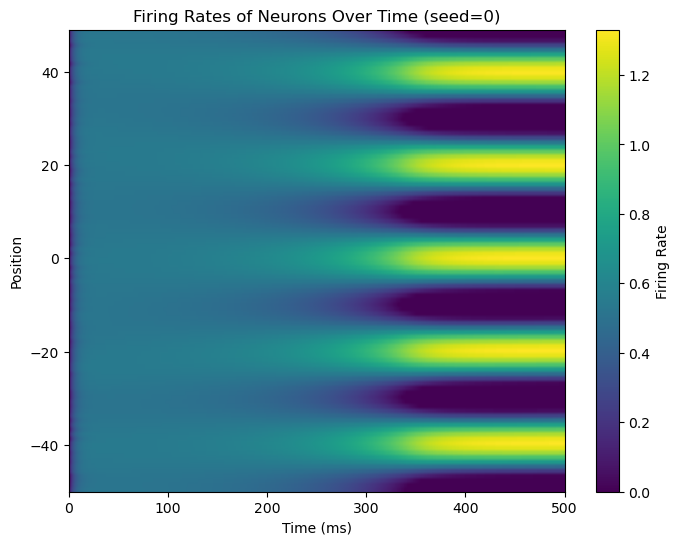

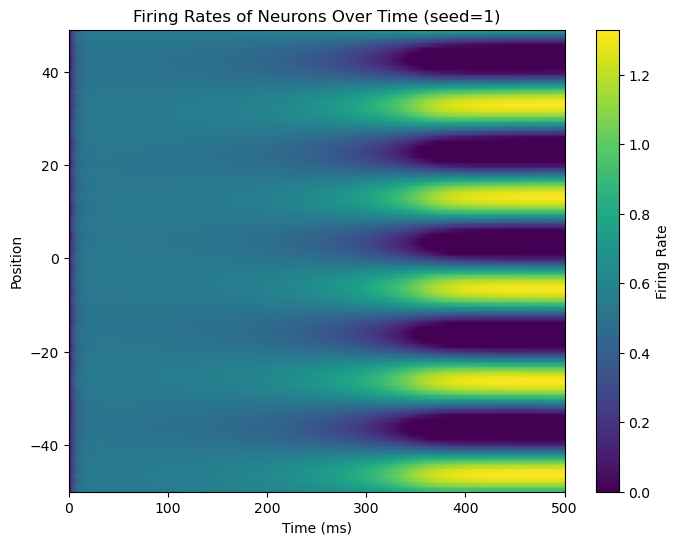

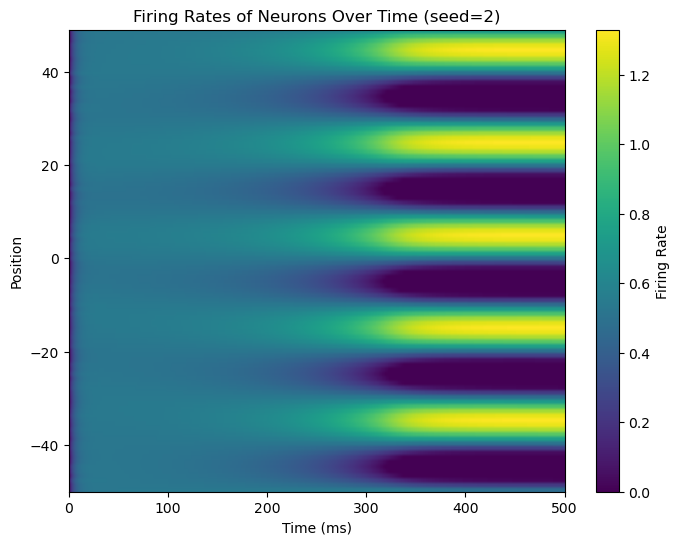

In [22]:
for seed in [0, 1, 2]:
    r_history = forward_Euler(M=M, W=W, B=B, dt=dt, tau=tau, n_steps=n_steps, seed=seed)
    plot_firing_rates(r_history, x, n_steps, seed=seed)

### Answer:
The network self organizes from a random initial state to a stable pattern of periodic activity bumps. These bumps arrives around 200ms and stay constant after that. That reflects the attractor dynamic of the network A bump corresponds to a group of neurons firing together via local excitation and neurons between the bumps are inhibited via lateral inhibition.

When we plot for 3 different seeds, we can see:
- Number of bumps and their spacing are identical. These parameters are determined by the sigmas.
- Amplitude of bumps is the same. Determined by A_exc and A_inh.
- Position of the bumps differs. So the position depends on the initialisation of $s(x,0)$. The position is not fixed by the connectivity but by the history of the network.




## Exercise 1 — 1D Velocity Integration

To track velocity, we include two sub-populations in the network: a “Right-shifting” population (R) and a “Left-shifting” population (L), each with $M = 100$ neurons. There are two neurons at each location $x$, one neuron for each population. The recurrent connectivity and external input are defined as follows:

- The connection weights coming from the R population are shifted slightly to the right by a weight shift $l$, meaning a neuron at $x'$ in R projects to a neuron at $x$ with weight:
$$
W_R(x - x') = W(x - x' - l)
$$

- The connection weights coming from the L population are shifted to the left by $l$:
$$
W_L(x - x') = W(x - x' + l)
$$

- Each population receives its own external input, $B_R$ and $B_L$, which is modulated asymmetrically by an external velocity signal $v(t)$:
$$
B_R(x,t) = B_0(1 + \alpha v(t))
$$
$$
B_L(x,t) = B_0(1 - \alpha v(t))
$$

Both populations project to each other as well as to themselves. The total recurrent input received by any neuron (whether it belongs to the R or L population) is the sum of inputs from both populations:

$$
I_{rec}(x,t) =
\int W_R(x - x') r_R(x',t)\,dx' +
\int W_L(x - x') r_L(x',t)\,dx'
$$

### 1.1
Write a simulation class or function for this 2-population integrator. Use the previous parameters, but set:

- $B_0 = 1.5$
- $\alpha = 0.5$
- $l = 1.0$

Run the simulation for $1000$ ms with a timestep of $1$ ms.

For the first $300$ ms, set $v = 0$ to let the activity pattern stabilize, and you should observe stable bumps. From $t = 300$ ms to $700$ ms, apply a constant velocity $v = 1.0$. For $t > 700$ ms, set $v = 0$.

Plot the sum of the firing rates:

$$
r_{total}(x,t) = r_R(x,t) + r_L(x,t)
$$

### 1.2
Explain how the asymmetric scaling of the external inputs leads to shifting bumps in response to a velocity signal, based on the interactions between the two populations.

### 1.3
To show that the bump acts as a velocity integrator, we apply a velocity signal $v$ of varying magnitudes over time.

Sample $10$ velocities in the interval:

$$
[-2, -0.5] \cup [0.5, 2]
$$

The velocity changes every $300$ timesteps.

Plot the evolution of the bump and the velocity signal side by side. Describe your observations.

### 1.4
Devise a method to compute the drifting speed of the 1D bump pattern. Use this method to extract the bump drifting speed at different input velocities $v$ sampled in 1.3.

Plot the drifting speed versus the actual input velocity.

Can you see a linear relationship between the two?

## Exercise 2 — Extending to 2D Grid Cells

We now extend to a 2D sheet of neurons. Each neuron has a 2D position $\vec{x} = (x, y)$. Then equations (1) and (2) can be directly extended for the 2D case by using $\vec{x}$ and $\vec{x}'$ to replace $x$ and $x'$.

The Mexican-hat connectivity in 2D is defined using the Euclidean norm of the vector:

$$
||\vec{x}|| = \sqrt{x^2 + y^2}
$$

$$
W(\vec{x}) = A_{exc} e^{-||\vec{x}||^2 / \sigma_{exc}^2} - A_{inh} e^{-||\vec{x}||^2 / \sigma_{inh}^2}
$$

### 2.1
Consider an $M \times M$ array of neurons ($M = 40$, so $1600$ neurons), plot the mexican-hat weight kernel $W(\vec{x})$ centered around $0$ in a 2D heatmap (i.e., $x, y \in [-\frac{M}{2}, \frac{M}{2})$, equally spaced). Use parameters:

- $A_{exc} = 1.0$
- $A_{inh} = 1.0$
- $\sigma_{exc} = 4.8$
- $\sigma_{inh} = 5.0$

To model movement in the 2D space, we use 4 distinct populations: North (N), South (S), East (E), and West (W), each with 2D Mexican-hat kernels shifted by a weight shift $l$ along their respective preferred axes:

$$
W_N(\vec{x}) = W(\vec{x} - (0, l)) \quad W_S(\vec{x}) = W(\vec{x} + (0, l))
$$

$$
W_E(\vec{x}) = W(\vec{x} - (l, 0)) \quad W_W(\vec{x}) = W(\vec{x} + (l, 0))
$$

The feedforward inputs are modulated by a 2D velocity vector $\vec{v}(t) = (v_x(t), v_y(t))$:

$$
B_N = B_0(1 + \alpha v_y(t)) \quad B_S = B_0(1 - \alpha v_y(t))
$$

$$
B_E = B_0(1 + \alpha v_x(t)) \quad B_W = B_0(1 - \alpha v_x(t))
$$

### 2.2
Implement the 2D model. Create an $M \times M$ array of neurons ($M = 40$). Use the above mexican-hat kernel as 2D connectivity with periodic boundary (topologically, connecting the boundaries of a 2D sheet means that the neurons lie on a torus).

Simulate with $\vec{v} = (0,0)$ until the pattern stabilizes (e.g., $400$ ms). Plot a heatmap of the total 2D firing rate:

$$
r_{total}(x,y)
$$

(sum of all 4 populations) at the final timestep.

Do you see a grid pattern?

Use parameters:

- $\tau = 10 \, \text{ms}$
- $\Delta t = 1 \, \text{ms}$
- $l = 1.0$
- $\alpha = 0.1$
- $B_0 = 1.0$

### 2.3
To test that your grid maps act as a continuous 2D integrator, apply constant velocity vectors in at least 3 different directions (e.g., purely horizontal, purely vertical, and diagonal).

For each velocity direction:

- run your network without any velocity for $300$ ms
- then apply input velocity for $300$ ms

Visualize the total 2D firing rate $r_{total}(x,y)$ side-by-side at 3 distinct time points (e.g., $t = 300$, $t = 450$, $t = 600$ ms).

Describe the integration motion resulting from your velocity input vectors.

Hint: Convolution over the 2D space can be easily implemented using `scipy.ndimage.convolve2d` and setting the boundary conditions accordingly. 
Personal warning: `scipy.ndimage.convolve2d` doesn't exist, we will use `scipy.ndimage.convolve`.

### 2.4 (Bonus)
Generate an input pattern with changing velocity.

Start with a velocity pointing in a random direction, with a speed sampled uniformly in $[1, 2]$. Sample a new velocity every $100$ ms, and you could smooth the velocity when there is a change.

Estimate the input velocity $\vec{v}$ from the drifting of the grid patterns.

Does it track well the input velocity?

## Exercise 3 — Aperiodic Boundaries

Periodic boundaries (a torus connection topology) are biologically implausible as raw physical tissue does not wrap around itself. The edges of the neural tissue must be considered.

We now consider the aperiodic boundary: if the source neuron of a connection weight exceeds the boundary, we just omit the connection.

Mathematically, we define a strict boundary for integrals in the expression of $I_{rec}(\vec{x}, t)$:

$$
I_{rec}(\vec{x}, t) =
\int_0^M \int_0^M W(\vec{x} - \vec{x}') r(\vec{x}', t)\,dx'\,dy'
$$

If you are using `scipy.ndimage.convolve2d`, this could be efficiently implemented by setting `mode='constant'`.

### 3.1
Repeat the simulation from Ex. 2.2 but with aperiodic boundaries. Describe what you see.

To recover the grid pattern with aperiodic boundaries, there are two proposed methods:

- attenuate the outgoing weights for neurons near the boundary
- attenuate the input for neurons near the boundary

The intuition is that these methods reduce the influence of artifacts at the boundary.

We define a radial masking envelope $e(\vec{x})$ that equals $1$ in the center and smoothly tapers to $0$ near the boundaries:

$$
e(\vec{x}) = \exp\left(-\gamma^2 \max(0, |\vec{x}| - R_{fade})^2 \right)
$$

where:

- $|\vec{x}|$ is the distance from the center
- $R_{fade} = f_{ratio} \cdot \frac{M}{2}$
- $\gamma$ controls the exponential fall-off

Use:

- $\gamma = 0.08$
- $f_{ratio} = 0.2$

Because we want to attenuate the boundary effects, we enlarge the network to $M = 50$.


### 3.2
Compute and plot the 2D radial masking envelope $e(\vec{x})$.

### 3.3
Modify your network such that the outgoing weights of boundary neurons are scaled by $e(\vec{x})$.

(Hint: this is equivalent to scaling the firing rates $r_{N,S,E,W}$ by $e(\vec{x})$ before performing the convolution.)

Simulate with $\vec{v} = (0,0)$ and plot the final network activity:

$$
r_{total}(x,y)
$$

Describe the pattern.

### 3.4
Instead of attenuating the weights, modulate the velocity inputs:

Multiply $B_N, B_S, B_E, B_W$ by the envelope $e(\vec{x})$ (making the input position-dependent).

Repeat the simulation and plot as in Ex. 3.3.

Comment on the resulting pattern.

### 3.5
What is the difference between the two approaches in Ex. 3.3 and 3.4?

Is one better than the other?

Does this have biological consequences or implications?

### 3.6 (Bonus)
Use the model in Ex. 3.4.

Generate a velocity signal with fixed amplitude and step-wise changing direction over time.

Estimate the velocity from the drifting of the grid patterns.

Does it track well the input velocity?

Do you notice any change in the pattern other than following the velocity input?

## Exercise 4 — Final Question

Please select ONLY ONE of the following three questions and answer it in half a page of free text.

Conceptually this is the most challenging part of the miniproject! You need to think deeply and really understand the issues before you answer.

You can choose the question that fits best your background and interests.

For this final question you are NOT allowed to discuss with other teams of students working on the same project.

---

### 4.1 (Theory-oriented)
Assuming that your project works well and has all the qualitative features that you expect it to have.

Can you think of a special case of the model for which you can derive mathematically the exact answer, using the mathematical theories covered in class (for example field models)?

How could you use this to PRECISELY test your program, to make sure that it is quantitatively correct?

Hint: What type of mismatch would you expect if either the theory calculations or the model simulations are wrong by a factor of 2 at an unknown location?

Test your model for quantitative correctness.

---

### 4.2 (Coding-oriented)
This miniproject was inspired by the paper from Burak and Fiete (2009).

In the paper, they described their simulation and parameters in the following rephrased paragraph (on the next page).

What is the EXACT mapping between your code and the description in the paper?

If there are differences, what are they?

---

### 4.3 (Biology-oriented)
This miniproject in computational neuroscience should have a link to neurobiology.

Be creative and design an experiment that would enable you to test specific aspects of the model predictions.

If necessary, think of additional modules or features that you would have to add to your model to make a comparison with experiments possible.